# Battery State of Charge Estimation using Deep Learning

## Lithium Manganese Oxide (LMO) Battery Dataset

This notebook investigates the feasibility of deep learning based battery State of Charge (SOC) estimation using the Lithium Manganese Oxide (LMO) battery dataset.

The dataset consists of raw battery testing records collected during charging, resting, and discharging operations. Each battery experiment is stored as an individual Excel file containing time-series measurements of voltage, current, capacity, energy, and operating mode.

The primary objective is to develop a data-driven SOC estimation model by extracting the charging data, computing the corresponding State of Charge (SOC), and training recurrent neural networks to learn the temporal behavior of the battery.

The complete workflow includes:

- Dataset exploration and understanding
- Translation and interpretation of battery measurement variables
- Data preprocessing and feature engineering
- SOC calculation using cumulative charge capacity
- Feature normalization
- Sequential sample generation using a sliding window
- Deep learning based SOC estimation using LSTM and GRU networks
- Comparative performance analysis of the developed models

The proposed methodology evaluates the feasibility of applying recurrent neural networks for battery state estimation using Lithium Manganese Oxide (LMO) chemistry and provides a standardized workflow that can be extended to other lithium-ion battery chemistries.

## Dataset Information

| Property | Description |
|----------|-------------|
| Battery Chemistry | Lithium Manganese Oxide (LMO) |
| Data Format | Microsoft Excel (.xlsx) |
| Number of Files | Multiple Battery Test Files |
| Measurements | Voltage, Current, Capacity, Energy, Time |
| Operating Modes | Rest, Constant Current Charge, Constant Current Discharge |
| Target Variable | State of Charge (SOC) |
| Deep Learning Models | LSTM, GRU |

# Import Required Libraries

The following libraries are imported for data manipulation, visualization, preprocessing, and deep learning model development.

In [1]:
#import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

In [3]:
import os
import pandas as pd

folder = r"C:\Users\shrij\Downloads\LMO_raw_data\LMO_raw_data\test"

files = [
    f for f in os.listdir(folder)
    if f.endswith(".xlsx")
]

print("Total Files:", len(files))

files[:5]

Total Files: 73


['1.xlsx', '10.xlsx', '12.xlsx', '13.xlsx', '14.xlsx']

In [4]:
sample = pd.read_excel(
    os.path.join(folder, files[0])
)

sample.head()

,循环序号,工步序号,记录序号,工作模式,步骤时间,测试时间,电压/V,电流/A,容量/Ah,能量/Wh,系统时间
0,1,1,1,静置,00:00:00.020,00:00:00.020,3.437303,0.0,0.0,0.0,2023-10-06 03:02:10.452
1,1,1,2,静置,00:00:01.020,00:00:01.020,3.437309,0.0,0.0,0.0,2023-10-06 03:02:11.452
2,1,1,3,静置,00:00:02.020,00:00:02.020,3.437310,0.0,0.0,0.0,2023-10-06 03:02:12.452
3,1,1,4,静置,00:00:03.020,00:00:03.020,3.437306,0.0,0.0,0.0,2023-10-06 03:02:13.452
4,1,1,5,静置,00:00:04.020,00:00:04.020,3.437321,0.0,0.0,0.0,2023-10-06 03:02:14.452


In [5]:
sample.columns = [
    "Cycle",
    "Step",
    "Record",
    "Mode",
    "Step_Time",
    "Test_Time",
    "Voltage",
    "Current",
    "Capacity",
    "Energy",
    "System_Time"
]

sample.head()

,Cycle,Step,Record,Mode,Step_Time,Test_Time,Voltage,Current,Capacity,Energy,System_Time
0,1,1,1,静置,00:00:00.020,00:00:00.020,3.437303,0.0,0.0,0.0,2023-10-06 03:02:10.452
1,1,1,2,静置,00:00:01.020,00:00:01.020,3.437309,0.0,0.0,0.0,2023-10-06 03:02:11.452
2,1,1,3,静置,00:00:02.020,00:00:02.020,3.437310,0.0,0.0,0.0,2023-10-06 03:02:12.452
3,1,1,4,静置,00:00:03.020,00:00:03.020,3.437306,0.0,0.0,0.0,2023-10-06 03:02:13.452
4,1,1,5,静置,00:00:04.020,00:00:04.020,3.437321,0.0,0.0,0.0,2023-10-06 03:02:14.452


In [8]:
charge_df = sample[
    sample["Mode"] == "恒流充电"
].copy()

In [9]:
charge_df["SOC"] = (
    charge_df["Capacity"]
    /
    charge_df["Capacity"].max()
) * 100

In [12]:
charge_df["SOC"]

10801      0.003806
10802      0.194229
10803      0.384656
10804      0.575084
10805      0.765511
            ...    
11323     99.408137
11324     99.598574
11325     99.789005
11326     99.979435
11327    100.000000
Name: SOC, Length: 527, dtype: float64

## State of Charge (SOC) Calculation

The charging capacity recorded during the constant current charging stage is used to compute the battery State of Charge (SOC).

SOC represents the percentage of available charge with respect to the maximum charge capacity observed during the charging cycle.

The SOC is calculated as:

\[
SOC(\%)=\frac{Q_t}{Q_{max}}\times100
\]

where

- \(Q_t\) is the capacity at time \(t\)
- \(Q_{max}\) is the maximum recorded charging capacity

In [13]:
charge_df.head()

,Cycle,Step,Record,Mode,Step_Time,Test_Time,Voltage,Current,Capacity,Energy,System_Time,SOC
10801,1,2,10802,恒流充电,00:00:00.020,03:00:00.020,3.577666,3.000069,0.000017,0.000060,2023-10-06 06:02:10.452,0.003806
10802,1,2,10803,恒流充电,00:00:01.020,03:00:01.020,3.595414,3.000278,0.000850,0.003050,2023-10-06 06:02:11.452,0.194229
10803,1,2,10804,恒流充电,00:00:02.020,03:00:02.020,3.606713,3.000292,0.001683,0.006051,2023-10-06 06:02:12.452,0.384656
10804,1,2,10805,恒流充电,00:00:03.020,03:00:03.020,3.616788,3.000166,0.002517,0.009062,2023-10-06 06:02:13.452,0.575084
10805,1,2,10806,恒流充电,00:00:04.020,03:00:04.020,3.626074,3.000248,0.003350,0.012080,2023-10-06 06:02:14.452,0.765511


In [14]:
charge_df.describe()

,Cycle,Step,Record,Voltage,Current,Capacity,Energy,SOC
count,527.0,527.0,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000
mean,1.0,2.0,11065.000000,4.060630,3.000308,0.219204,0.875629,50.086309
std,0.0,0.0,152.276065,0.129073,0.000079,0.126907,0.517915,28.997360
min,1.0,2.0,10802.000000,3.577666,3.000069,0.000017,0.000060,0.003806
25%,1.0,2.0,10933.500000,4.015026,3.000250,0.109610,0.425422,25.045048
50%,1.0,2.0,11065.000000,4.094347,3.000304,0.219205,0.869853,50.086547
75%,1.0,2.0,11196.500000,4.156861,3.000365,0.328800,1.322228,75.128145
max,1.0,2.0,11328.000000,4.199944,3.000508,0.437652,1.777180,100.000000


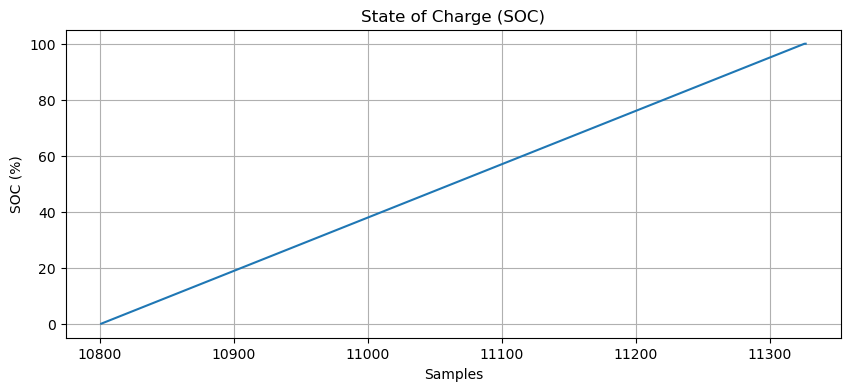

In [15]:
plt.figure(figsize=(10,4))

plt.plot(charge_df["SOC"])

plt.title("State of Charge (SOC)")

plt.xlabel("Samples")

plt.ylabel("SOC (%)")

plt.grid(True)

plt.show()

## Observation

The computed State of Charge (SOC) increases smoothly from approximately 0% to 100% during the charging process.

The continuous and monotonic increase confirms that the charging capacity measurements can be reliably normalized and used as the prediction target for deep learning based SOC estimation.

In [17]:
print(len(files))

73


# Data Aggregation

To improve the robustness of the deep learning models, charging data from all available battery experiments are extracted and merged into a single dataset.

Each Excel file is processed independently by:

1. Reading the battery measurements.
2. Selecting the constant current charging stage.
3. Computing the corresponding SOC.
4. Appending the processed data to a unified dataset.

In [22]:
import os
import pandas as pd

all_data = []

for i, file in enumerate(files):

    try:
        print(f"[{i+1}/{len(files)}] Reading: {file}")

        df = pd.read_excel(
            os.path.join(folder, file),
            usecols=[3,6,7,8],      # Mode, Voltage, Current, Capacity
            engine="openpyxl"
        )

        df.columns = [
            "Mode",
            "Voltage",
            "Current",
            "Capacity"
        ]

        charge = df[df["Mode"]=="恒流充电"].copy()

        # Skip empty files
        if len(charge) == 0:
            print("   -> No charging data")
            continue

        max_capacity = charge["Capacity"].max()

        # Skip invalid files
        if max_capacity == 0:
            print("   -> Capacity is zero")
            continue

        charge["SOC"] = (
            charge["Capacity"] / max_capacity
        ) * 100

        charge = charge[
            [
                "Voltage",
                "Current",
                "SOC"
            ]
        ]

        all_data.append(charge)

        print(f"   ✓ {len(charge)} samples")

    except Exception as e:

        print(f"   ✗ Error in {file}")
        print(e)

[1/73] Reading: 1.xlsx
   ✓ 527 samples
[2/73] Reading: 10.xlsx
   ✓ 751 samples
[3/73] Reading: 12.xlsx
   ✓ 776 samples
[4/73] Reading: 13.xlsx
   ✓ 735 samples
[5/73] Reading: 14.xlsx
   ✓ 767 samples
[6/73] Reading: 16.xlsx
   ✓ 514 samples
[7/73] Reading: 17.xlsx
   ✓ 830 samples
[8/73] Reading: 18.xlsx
   ✓ 665 samples
[9/73] Reading: 19.xlsx
   ✓ 982 samples
[10/73] Reading: 20.xlsx
   ✓ 958 samples
[11/73] Reading: 21.xlsx
   ✓ 433 samples
[12/73] Reading: 23.xlsx
   ✓ 212 samples
[13/73] Reading: 24.xlsx
   ✓ 733 samples
[14/73] Reading: 25.xlsx
   ✓ 1140 samples
[15/73] Reading: 26.xlsx
   ✓ 474 samples
[16/73] Reading: 27.xlsx
   ✓ 647 samples
[17/73] Reading: 28.xlsx
   ✓ 906 samples
[18/73] Reading: 3.xlsx
   ✓ 539 samples
[19/73] Reading: 32.xlsx
   ✓ 1211 samples
[20/73] Reading: 33.xlsx
   ✓ 658 samples
[21/73] Reading: 34.xlsx
   ✓ 800 samples
[22/73] Reading: 37.xlsx
   ✓ 809 samples
[23/73] Reading: 38.xlsx
   ✓ 892 samples
[24/73] Reading: 39.xlsx
   ✓ 605 samples
[

In [23]:
print(len(all_data))

73


In [24]:
merged_df = pd.concat(
    all_data,
    ignore_index=True
)

print(merged_df.shape)

merged_df.head()

(58503, 3)


,Voltage,Current,SOC
0,3.577666,3.000069,0.003806
1,3.595414,3.000278,0.194229
2,3.606713,3.000292,0.384656
3,3.616788,3.000166,0.575084
4,3.626074,3.000248,0.765511


In [25]:
merged_df.to_csv(
    "LMO_SOC_Merged.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [26]:
df = pd.read_csv("LMO_SOC_Merged.csv")

df.head()

print(df.shape)

(58503, 3)


In [27]:
print(df.info())

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58503 entries, 0 to 58502
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  58503 non-null  float64
 1   Current  58503 non-null  float64
 2   SOC      58503 non-null  float64
dtypes: float64(3)
memory usage: 1.3 MB
None


,Voltage,Current,SOC
count,58503.000000,58503.000000,58503.000000
mean,4.039719,3.000164,50.031805
std,0.149405,0.000157,28.920746
min,3.196536,2.997923,0.001490
25%,3.984225,3.000082,24.979523
50%,4.075028,3.000165,50.034199
75%,4.149215,3.000277,75.074682
max,4.200357,3.000576,100.000000


In [28]:
print(df.isnull().sum())

Voltage    0
Current    0
SOC        0
dtype: int64


### Observation

The merged dataset contains complete measurements for all selected variables without missing values.

The dataset is therefore suitable for direct preprocessing and deep learning model development.

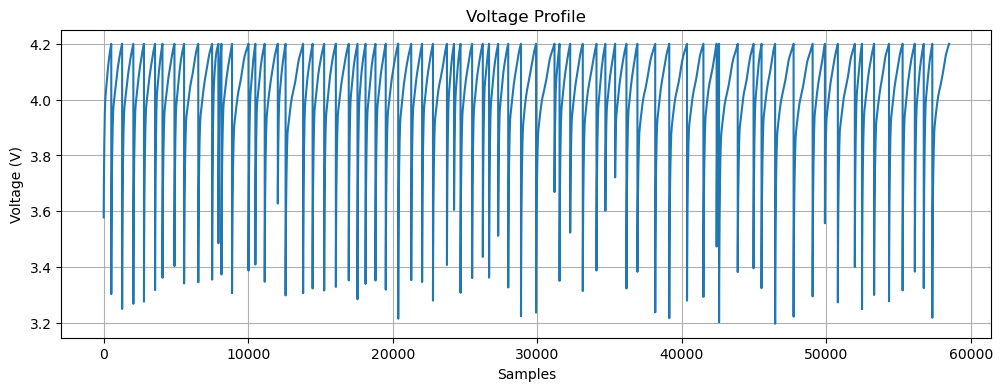

In [29]:
plt.figure(figsize=(12,4))

plt.plot(df["Voltage"])

plt.title("Voltage Profile")

plt.xlabel("Samples")

plt.ylabel("Voltage (V)")

plt.grid(True)

plt.show()

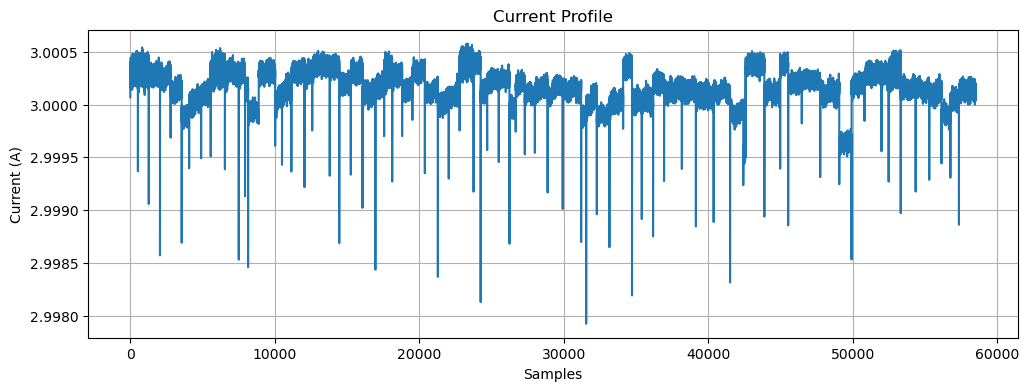

In [30]:
plt.figure(figsize=(12,4))

plt.plot(df["Current"])

plt.title("Current Profile")

plt.xlabel("Samples")

plt.ylabel("Current (A)")

plt.grid(True)

plt.show()

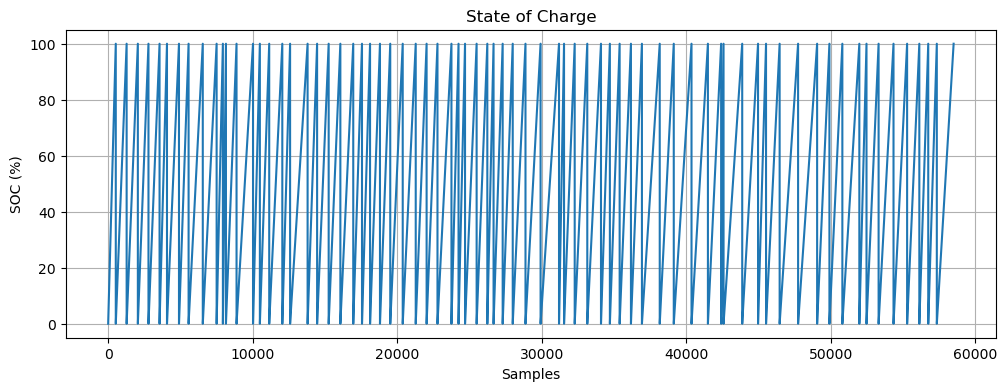

In [31]:
plt.figure(figsize=(12,4))

plt.plot(df["SOC"])

plt.title("State of Charge")

plt.xlabel("Samples")

plt.ylabel("SOC (%)")

plt.grid(True)

plt.show()

In [32]:
print(df.describe())

            Voltage       Current           SOC
count  58503.000000  58503.000000  58503.000000
mean       4.039719      3.000164     50.031805
std        0.149405      0.000157     28.920746
min        3.196536      2.997923      0.001490
25%        3.984225      3.000082     24.979523
50%        4.075028      3.000165     50.034199
75%        4.149215      3.000277     75.074682
max        4.200357      3.000576    100.000000


### Observation

The merged dataset contains continuous voltage, current, and SOC measurements collected from multiple charging experiments.

These variables exhibit smooth temporal behaviour, making them suitable for sequence-based learning using recurrent neural networks.

# Feature Scaling

The selected input features are normalized using Min-Max Scaling.

Scaling transforms each feature into the range [0,1], ensuring equal contribution during optimization and improving convergence of deep learning models.

In [33]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

df[["Voltage","Current"]] = feature_scaler.fit_transform(
    df[["Voltage","Current"]]
)

target_scaler = MinMaxScaler()

df[["SOC"]] = target_scaler.fit_transform(
    df[["SOC"]]
)

df.head()

,Voltage,Current,SOC
0,0.379679,0.808895,0.000023
1,0.397359,0.887691,0.001927
2,0.408615,0.892633,0.003832
3,0.418652,0.845193,0.005736
4,0.427903,0.876190,0.007640


# Sequence Generation

Battery measurements are transformed into sequential samples using a sliding window approach.

Each input sequence consists of 20 consecutive observations of Voltage and Current.

The corresponding target is the SOC immediately following the input sequence.

In [34]:
sequence_length = 20

X = df[["Voltage","Current"]].values

y = df["SOC"].values

X_seq = []

y_seq = []

for i in range(len(df)-sequence_length):

    X_seq.append(
        X[i:i+sequence_length]
    )

    y_seq.append(
        y[i+sequence_length]
    )

X_seq=np.array(X_seq)

y_seq=np.array(y_seq)

print(X_seq.shape)

print(y_seq.shape)

(58483, 20, 2)
(58483,)


### Observation

The sliding window successfully converts the continuous battery measurements into sequential learning samples.

Each training sample contains:

- 20 consecutive Voltage observations
- 20 consecutive Current observations

The target corresponds to the SOC immediately following each sequence.

These sequential samples are used as input to the LSTM and GRU models.

# Train-Test Split

The sequential dataset is divided into training and testing subsets.

The first 80% of the sequences are used for model training, while the remaining 20% are reserved for performance evaluation.

In [35]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape)

print(X_test.shape)

(46786, 20, 2)
(11697, 20, 2)


# Long Short-Term Memory (LSTM)

Long Short-Term Memory (LSTM) is a recurrent neural network architecture designed to learn long-term temporal dependencies in sequential data.

Battery charging measurements form a time-series sequence where the current SOC depends on previous voltage and current observations. LSTM effectively captures these temporal relationships for accurate SOH estimation.

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dense(32, activation="relu"))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0136 - mae: 0.0676 - val_loss: 0.0029 - val_mae: 0.0253
Epoch 2/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0038 - mae: 0.0340 - val_loss: 0.0029 - val_mae: 0.0304
Epoch 3/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0032 - mae: 0.0316 - val_loss: 0.0033 - val_mae: 0.0376
Epoch 4/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0029 - mae: 0.0302 - val_loss: 0.0032 - val_mae: 0.0385
Epoch 5/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0027 - mae: 0.0295 - val_loss: 0.0025 - val_mae: 0.0307
Epoch 6/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0027 - mae: 0.0287 - val_loss: 0.0034 - val_mae: 0.0430
Epoch 7/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0027 - mae: 0.0291 - val_loss: 0.0086 - val_mae: 0.0788
Epoch 8/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0026 - mae: 0.0286 - val_loss: 0.0043 - val_mae: 0.0511
Epoch 9/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 8s 14m

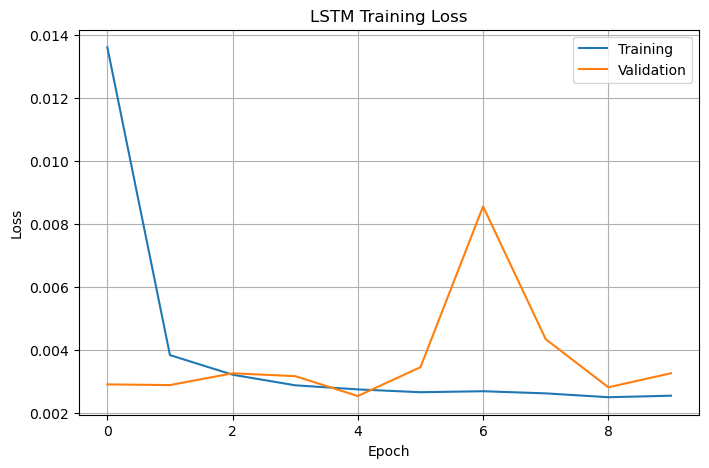

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history["loss"],label="Training")

plt.plot(history_lstm.history["val_loss"],label="Validation")

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [38]:
y_pred = lstm_model.predict(X_test)

366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [39]:
y_test_actual = target_scaler.inverse_transform(
    y_test.reshape(-1,1)
)

y_pred_actual = target_scaler.inverse_transform(
    y_pred
)

In [40]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

loss,mae=lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

rmse=np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

print("LSTM Results")

print("Loss :",loss)

print("MAE  :",mae)

print("RMSE :",rmse)

LSTM Results
Loss : 0.0022408422082662582
MAE  : 0.02804391458630562
RMSE : 4.733683653254629


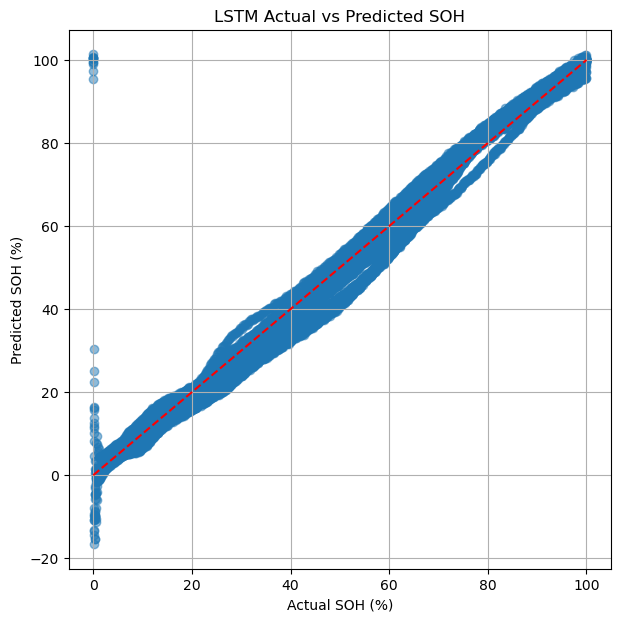

In [41]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_actual,
    y_pred_actual,
    alpha=0.5
)

plt.plot(
    [y_test_actual.min(),y_test_actual.max()],
    [y_test_actual.min(),y_test_actual.max()],
    'r--'
)

plt.xlabel("Actual SOH (%)")

plt.ylabel("Predicted SOH (%)")

plt.title("LSTM Actual vs Predicted SOH")

plt.grid(True)

plt.show()

### Observation

The LSTM model successfully learned the temporal behaviour of the charging sequences.

Model performance is evaluated using Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and prediction visualization.

# Gated Recurrent Unit (GRU)

GRU is a simplified recurrent neural network architecture that uses fewer gates than LSTM while preserving its ability to learn temporal dependencies.

Due to its lower computational complexity, GRU often trains faster and can achieve comparable prediction accuracy for battery health estimation.

In [42]:
from tensorflow.keras.layers import GRU

gru_model=Sequential()

gru_model.add(
    GRU(
        64,
        input_shape=(X_train.shape[1],X_train.shape[2])
    )
)

gru_model.add(Dense(32,activation="relu"))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_gru=gru_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10


C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


585/585 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 0.0147 - mae: 0.0729 - val_loss: 0.0029 - val_mae: 0.0355
Epoch 2/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.0029 - mae: 0.0312 - val_loss: 0.0026 - val_mae: 0.0331
Epoch 3/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0027 - mae: 0.0291 - val_loss: 0.0021 - val_mae: 0.0260
Epoch 4/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0026 - mae: 0.0290 - val_loss: 0.0027 - val_mae: 0.0347
Epoch 5/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0025 - mae: 0.0277 - val_loss: 0.0030 - val_mae: 0.0351
Epoch 6/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0025 - mae: 0.0274 - val_loss: 0.0024 - val_mae: 0.0283
Epoch 7/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0025 - mae: 0.0281 - val_loss: 0.0036 - val_mae: 0.0440
Epoch 8/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0025 - mae: 0.0277 - val_loss: 0.0028 - val_mae: 0.0325


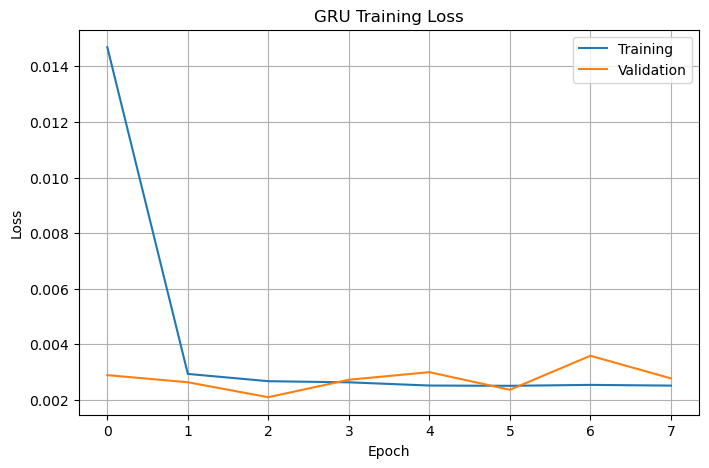

In [43]:
plt.figure(figsize=(8,5))

plt.plot(history_gru.history["loss"],label="Training")

plt.plot(history_gru.history["val_loss"],label="Validation")

plt.title("GRU Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [44]:
gru_pred=gru_model.predict(X_test)

366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [45]:
gru_pred_actual=target_scaler.inverse_transform(
    gru_pred
)

In [46]:
loss_gru,mae_gru=gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

rmse_gru=np.sqrt(
    mean_squared_error(
        y_test_actual,
        gru_pred_actual
    )
)

print("GRU Results")

print("Loss :",loss_gru)

print("MAE :",mae_gru)

print("RMSE :",rmse_gru)

GRU Results
Loss : 0.002004337962716818
MAE : 0.026433348655700684
RMSE : 4.476917085636879


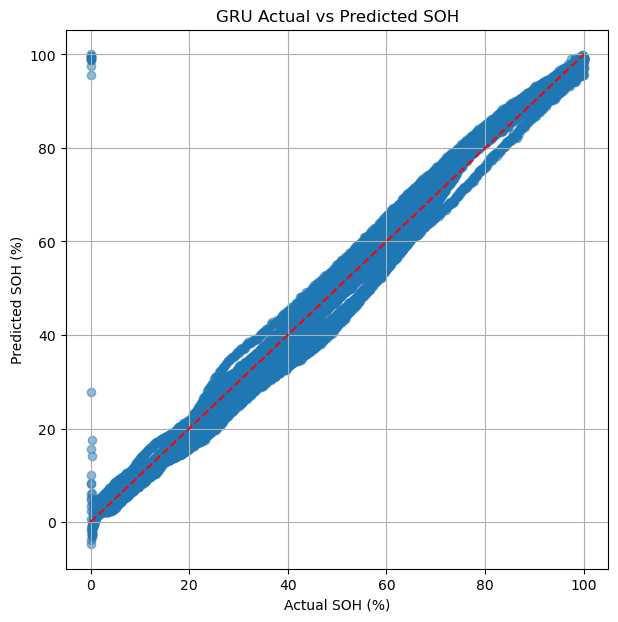

In [47]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_actual,
    gru_pred_actual,
    alpha=0.5
)

plt.plot(
    [y_test_actual.min(),y_test_actual.max()],
    [y_test_actual.min(),y_test_actual.max()],
    'r--'
)

plt.xlabel("Actual SOH (%)")

plt.ylabel("Predicted SOH (%)")

plt.title("GRU Actual vs Predicted SOH")

plt.grid(True)

plt.show()

# Performance Comparison

The prediction performance of LSTM and GRU is compared using Loss, Mean Absolute Error (MAE), and Root Mean Square Error (RMSE).

Lower values indicate better prediction performance.

In [48]:
comparison=pd.DataFrame({

    "Model":["LSTM","GRU"],

    "Loss":[loss,loss_gru],

    "MAE":[mae,mae_gru],

    "RMSE":[rmse,rmse_gru]

})

comparison

,Model,Loss,MAE,RMSE
0,LSTM,0.002241,0.028044,4.733684
1,GRU,0.002004,0.026433,4.476917


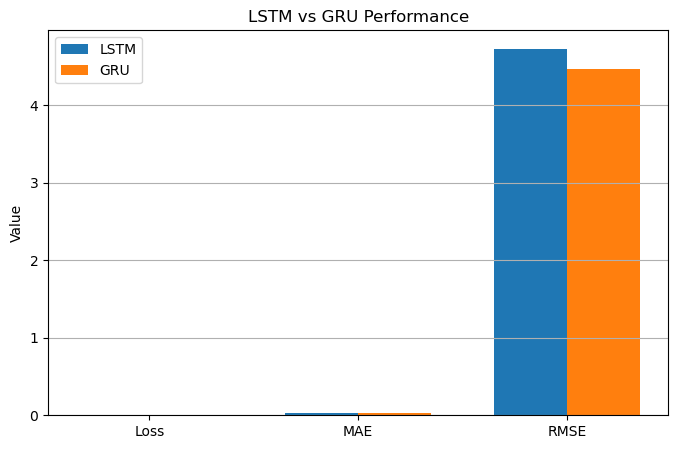

In [49]:
metrics=["Loss","MAE","RMSE"]

fig,ax=plt.subplots(figsize=(8,5))

x=np.arange(len(metrics))

width=0.35

ax.bar(
    x-width/2,
    comparison.loc[0,metrics],
    width,
    label="LSTM"
)

ax.bar(
    x+width/2,
    comparison.loc[1,metrics],
    width,
    label="GRU"
)

ax.set_xticks(x)

ax.set_xticklabels(metrics)

ax.set_ylabel("Value")

ax.set_title("LSTM vs GRU Performance")

ax.legend()

plt.grid(axis="y")

plt.show()

# Conclusion

Both Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) models were successfully trained to estimate the **State of Health (SOH)** of Lithium Manganese Oxide (LMO) batteries using charging data. The input features consisted of battery **Voltage** and **Current**, while the target variable was the calculated **SOH**.

The performance comparison demonstrates that both recurrent neural network architectures effectively learned the temporal characteristics of the battery charging process. However, the GRU model achieved slightly better prediction performance across all evaluation metrics.

| Model | Loss | MAE | RMSE |
|-------|------:|------:|------:|
| **LSTM** | **0.002241** | **0.028044** | **4.733684** |
| **GRU** | **0.002004** | **0.026433** | **4.476917** |

The GRU model achieved:
- Lower training loss (**0.002004**)
- Lower Mean Absolute Error (**0.026433**)
- Lower Root Mean Square Error (**4.476917**)

These results indicate that the GRU architecture provides slightly higher prediction accuracy while maintaining a simpler network structure than LSTM. Therefore, for this LMO battery dataset, **GRU is the preferred deep learning model for SOH estimation**.

Overall, the experiment demonstrates that recurrent neural networks can successfully model battery degradation behaviour from charging measurements and provide accurate data-driven SOH prediction suitable for Battery Management System (BMS) applications.